# AutoML AutoGluon #
Arhan Erdogan

#### Imports

In [29]:
from autogluon.tabular import TabularPredictor
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [30]:
script_dir = os.getcwd()
rel_path = "intermediate"

dataset = pd.read_csv(os.path.join(script_dir, rel_path, "CLEAN_data_injection_moulding.csv"))

#### Feature selection
2 different scenarios with and without ZUs as it dominates

In [31]:
# features = ['ZSx [s]', 'ACPx [cm³]', 'ZDx [s]', 'ZEx [s]', 'APHu [bar]', 'GEx [kWh]', 'GPx [kW]', 'HPx [kW]', 'HEx [kWh]', 'MPx [kW]', 'ESPx [kWh/kg]', 'H16x [°C]', 'H15x [°C]', 'H10x [°C]', 'H12x [°C]', 'H9x [°C]', 'H11x [°C]']

features = ['ZUs [s]','ZSx [s]', 'ACPx [cm³]', 'ZDx [s]', 'ZEx [s]', 'APHu [bar]', 'GEx [kWh]', 'GPx [kW]', 'HPx [kW]', 'HEx [kWh]', 'MPx [kW]', 'ESPx [kWh/kg]', 'H16x [°C]', 'H15x [°C]', 'H10x [°C]', 'H12x [°C]', 'H9x [°C]', 'H11x [°C]']

X = dataset[features]
y = dataset['ASZ [Sch]']
train_data = pd.concat([X, y], axis=1)

#### Train-Test split

In [32]:
train_df, test_df = train_test_split(train_data, test_size=0.2, random_state=42)

print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Scrap ratio in training: {train_df['ASZ [Sch]'].sum() / len(train_df):.3f}")

Training samples: 3883
Test samples: 971
Scrap ratio in training: 0.032


#### Training AutoGluon ####

In [33]:
predictor = TabularPredictor(
    label='ASZ [Sch]',
    eval_metric='f1',
    problem_type='binary',
    path='./autogluon_models'
).fit(
    train_data=train_df,
    time_limit=1200,
    presets='best_quality',
    verbosity=2
)

leaderboard = predictor.leaderboard(test_df, silent=True)
print("Model leaderboard")
print(leaderboard)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.3
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          16
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       2.64 GB / 15.41 GB (17.1%)
Disk Space Avail:   239.35 GB / 930.63 GB (25.7%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon

Model leaderboard
                          model  score_test  score_val eval_metric  \
0      RandomForest_r195_BAG_L1    1.000000   0.948617          f1   
1       RandomForestGini_BAG_L2    0.987013   0.980080          f1   
2               CatBoost_BAG_L1    0.986667   0.952756          f1   
3          CatBoost_r177_BAG_L1    0.986667   0.952756          f1   
4           CatBoost_r13_BAG_L1    0.986667   0.952756          f1   
5            CatBoost_r9_BAG_L1    0.986667   0.952756          f1   
6         ExtraTreesGini_BAG_L1    0.974359   0.953125          f1   
7         ExtraTrees_r42_BAG_L1    0.974359   0.953488          f1   
8        NeuralNetFastAI_BAG_L2    0.974359   0.984127          f1   
9           WeightedEnsemble_L3    0.974359   0.984127          f1   
10  NeuralNetFastAI_r191_BAG_L2    0.974359   0.984127          f1   
11      RandomForestEntr_BAG_L2    0.973684   0.976000          f1   
12        ExtraTreesGini_BAG_L2    0.973684   0.980080          f1   
13

#### Evaluation ####

In [34]:
y_pred = predictor.predict(test_df)
y_pred_proba = predictor.predict_proba(test_df)


print("Classification report")
print(classification_report(test_df['ASZ [Sch]'], y_pred))
AutoML_cr = classification_report(test_df['ASZ [Sch]'], y_pred,output_dict=True)

#storing classification report to be used in visuals
%store AutoML_cr

Classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       933
           1       0.93      1.00      0.96        38

    accuracy                           1.00       971
   macro avg       0.96      1.00      0.98       971
weighted avg       1.00      1.00      1.00       971

Stored 'AutoML_cr' (dict)


#### Confusion Matrix ####

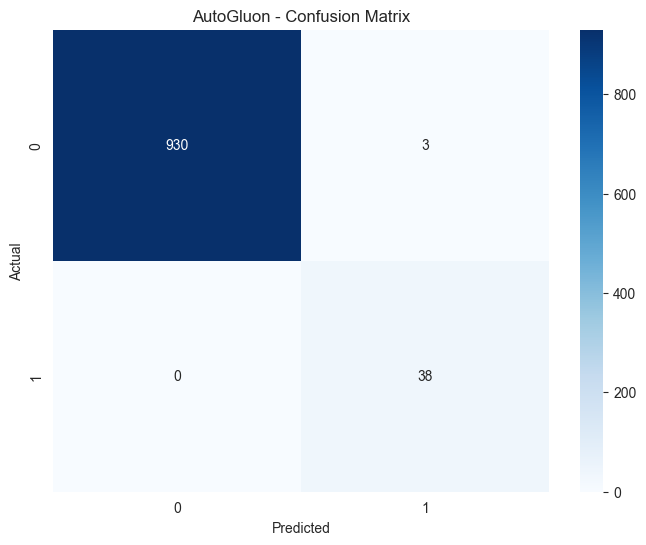

In [35]:
cm = confusion_matrix(test_df['ASZ [Sch]'], y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('AutoGluon - Confusion Matrix')
plt.show()

#### Feature importance ####

These features in provided data are not utilized by the predictor and will be ignored: ['APHu [bar]']
Computing feature importance via permutation shuffling for 17 features using 971 rows with 5 shuffle sets...
	18.87s	= Expected runtime (3.77s per shuffle set)
	8.51s	= Actual runtime (Completed 5 of 5 shuffle sets)



=== Feature Importance ===
               importance    stddev   p_value  n  p99_high   p99_low
ZUs [s]          0.452150  0.043619  0.000010  5  0.541962  0.362338
MPx [kW]         0.171422  0.045059  0.000524  5  0.264200  0.078644
GPx [kW]         0.104673  0.014282  0.000041  5  0.134081  0.075265
H16x [°C]        0.034153  0.006566  0.000156  5  0.047673  0.020633
ZSx [s]          0.018833  0.017532  0.037095  5  0.054932 -0.017265
GEx [kWh]        0.002405  0.005378  0.186950  5  0.013478 -0.008668
ESPx [kWh/kg]    0.002405  0.005378  0.186950  5  0.013478 -0.008668
ACPx [cm³]       0.000195  0.009069  0.482003  5  0.018869 -0.018479
HEx [kWh]        0.000000  0.000000  0.500000  5  0.000000  0.000000
H10x [°C]        0.000000  0.000000  0.500000  5  0.000000  0.000000
H9x [°C]         0.000000  0.000000  0.500000  5  0.000000  0.000000
ZDx [s]          0.000000  0.000000  0.500000  5  0.000000  0.000000
H15x [°C]        0.000000  0.000000  0.500000  5  0.000000  0.000000
H11x [

<Figure size 1000x600 with 0 Axes>

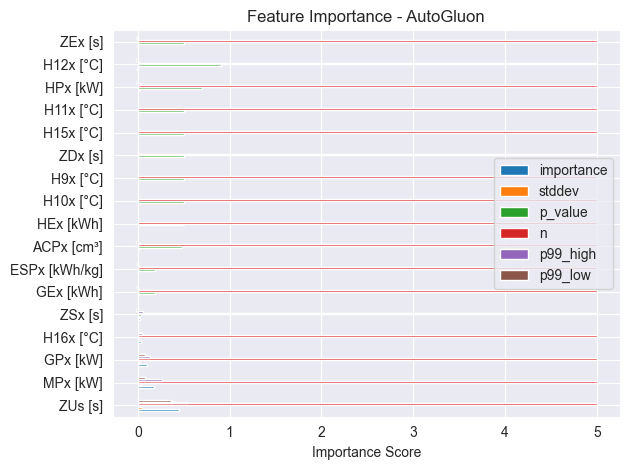

In [36]:
importance = predictor.feature_importance(test_df)
print("\n=== Feature Importance ===")
print(importance)

plt.figure(figsize=(10, 6))
importance.plot(kind='barh')
plt.xlabel('Importance Score')
plt.title('Feature Importance - AutoGluon')
plt.tight_layout()
plt.show()